In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import zscore
from scipy.stats import shapiro, normaltest, pearsonr, wilcoxon, spearmanr, kruskal, f_oneway, chi2_contingency

In [76]:
df1 = pd.read_csv(r"F:\DATA SCIENCE\Projects\Global Literacy & Educational Trends\data\featured\df_literacy.csv", index_col = 0)
df2 = pd.read_csv(r"F:\DATA SCIENCE\Projects\Global Literacy & Educational Trends\data\featured\df_illiteracy.csv", index_col = 0)
df3 = pd.read_csv(r"F:\DATA SCIENCE\Projects\Global Literacy & Educational Trends\data\featured\df_gdp_schooling.csv", index_col = 0)
df4 = pd.read_csv(r"F:\DATA SCIENCE\Projects\Global Literacy & Educational Trends\data\featured\df_edi.csv", index_col = 0)
df5 = pd.read_csv(r"F:\DATA SCIENCE\Projects\Global Literacy & Educational Trends\data\featured\df_eff.csv", index_col = 0)
df6 = pd.read_csv(r"F:\DATA SCIENCE\Projects\Global Literacy & Educational Trends\data\featured\strategic_feature_master.csv", index_col = 0)

# Univariate

## Literacy Distribution

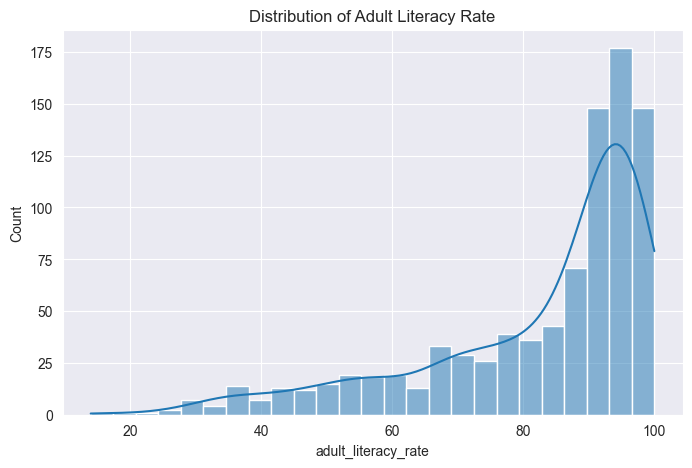

Mean:  82.68847382068452
Median:  90.07585
Skewness:  -1.385678228282779


In [77]:
# Adult Literacy Distribution
plt.figure(figsize = (8, 5))
sns.histplot(df5["adult_literacy_rate"], kde = True, bins = 25)
plt.title("Distribution of Adult Literacy Rate")
plt.show()

print("Mean: ", df5["adult_literacy_rate"].mean())
print("Median: ", df5["adult_literacy_rate"].median())
print("Skewness: ", df5["adult_literacy_rate"].skew())

### The adult literacy distribution shows a negative skew, indicating that most countries have literacy rates above 80%. However, a long lower tail suggests persistent educational challenges in certain developing regions.

In [78]:
# Testing for Normality
stat, p_value = shapiro(df5['adult_literacy_rate'])
print("Shapiro-Wilk Test Statistic: ", stat)
print("p_value: ", p_value)

if p_value > 0.05:
    print("Adult literacy distribution is approximately normal.")
else:
    print("Adult literacy distribution is NOT normal.")

Shapiro-Wilk Test Statistic:  0.8203648782542869
p_value:  1.7768545519309573e-30
Adult literacy distribution is NOT normal.


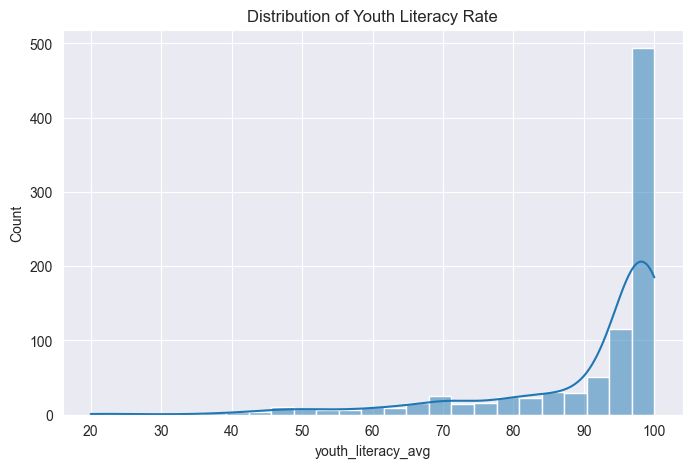

Mean:  90.89313944196428
Median:  97.5
Skewness:  -2.1264816050291704


In [79]:
# Youth Literacy Distribution
plt.figure(figsize = (8, 5))
sns.histplot(df5["youth_literacy_avg"], kde = True, bins = 25)
plt.title("Distribution of Youth Literacy Rate")
plt.show()

print("Mean: ", df5["youth_literacy_avg"].mean())
print("Median: ", df5["youth_literacy_avg"].median())
print("Skewness: ", df5["youth_literacy_avg"].skew())

In [80]:
# Testing for Normality
stat, p_value = shapiro(df5['youth_literacy_avg'])
print("Shapiro-Wilk Test Statistic: ", stat)
print("p_value: ", p_value)

if p_value > 0.05:
    print("Youth literacy distribution is approximately normal.")
else:
    print("Youth literacy distribution is NOT normal.")

Shapiro-Wilk Test Statistic:  0.6782394224994193
p_value:  4.2400636644392516e-38
Youth literacy distribution is NOT normal.


In [81]:
print("Adult Literacy Skew:", df5['adult_literacy_rate'].skew())
print("Youth Literacy Skew:", df5['youth_literacy_avg'].skew())

Adult Literacy Skew: -1.385678228282779
Youth Literacy Skew: -2.1264816050291704


### Youth literacy is significantly more concentrated at higher levels compared to adult literacy, indicating generational improvement in educational access.

### Youth literacy distribution is less skewed, confirming convergence in global education standards among younger populations.

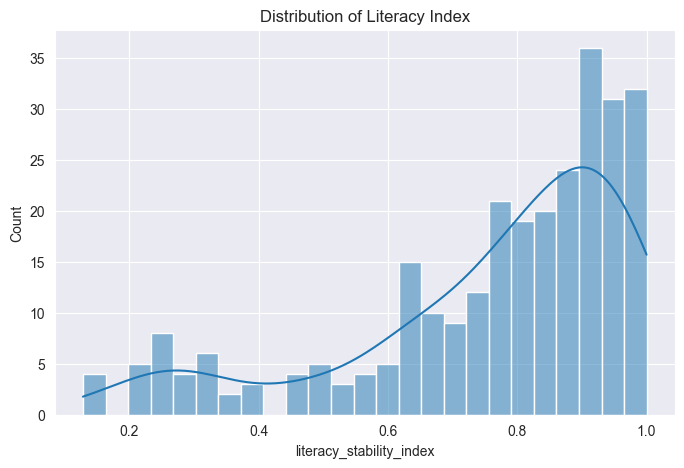

Mean:  0.7614982340522013
Median:  0.8273281884024317
Skewness:  -1.228229493080996


In [82]:
# Literacy Index Distribution
plt.figure(figsize = (8, 5))
sns.histplot(df1["literacy_stability_index"], kde = True, bins = 25)
plt.title("Distribution of Literacy Index")
plt.show()

print("Mean: ", df1["literacy_stability_index"].mean())
print("Median: ", df1["literacy_stability_index"].median())
print("Skewness: ", df1["literacy_stability_index"].skew())

### The literacy stability index shows a negatively skewed distribution, indicating that most countries maintain stable literacy progress over time. However, a minority of countries exhibit high volatility, likely due to structural, political, or economic instability. This highlights persistent global inequality in educational resilience.

In [83]:
# Testing for Normality
stat, p_value = shapiro(df5['literacy_stability_index'].dropna())
print("Shapiro-Wilk Test Statistic: ", stat)
print("p_value: ", p_value)

if p_value > 0.05:
    print("Youth literacy distribution is approximately normal.")
else:
    print("Youth literacy distribution is NOT normal.")

Shapiro-Wilk Test Statistic:  0.8609733457916303
p_value:  2.2216105405470245e-14
Youth literacy distribution is NOT normal.


## GDP Skewness

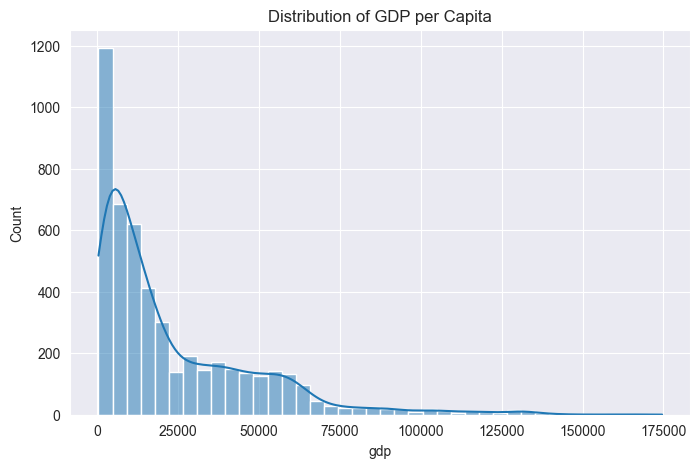

Mean: 23288.240335631224
Median: 13202.323
Skewness: 1.8005568874023081


In [84]:
# Raw GDP Distribution
plt.figure(figsize = (8, 5))
sns.histplot(df3["gdp"].dropna(), kde = True, bins = 40)
plt.title("Distribution of GDP per Capita")
plt.show()

print("Mean:", df3["gdp"].mean())
print("Median:", df3["gdp"].median())
print("Skewness:", df3["gdp"].skew())

### GDP per capita distribution is highly positively skewed, indicating that a small number of high-income countries significantly pull the average upward.

### Median GDP per capita is a better representation of the “typical country” than mean GDP.

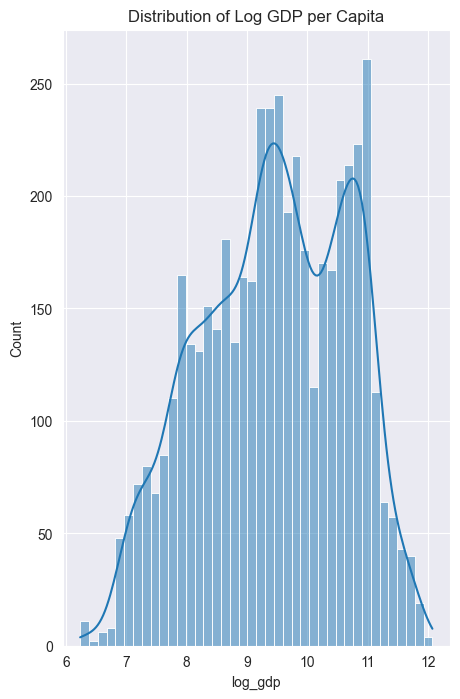

Skewness(Log GDP):  -0.2191062308186734


In [85]:
# Log-Transformed GDP
plt.figure(figsize = (5, 8))
sns.histplot(df3["log_gdp"].dropna(), kde = True, bins =40)
plt.title("Distribution of Log GDP per Capita")
plt.show()

print("Skewness(Log GDP): ", df3["log_gdp"].skew())

### Log transformation compresses extreme high-income values and reduces skewness, making GDP more suitable for correlation and regression analysis.

### The skewness dropped from 1.8 to -0.2 after log transformation, confirming that the transformation improved distribution symmetry and reduced extreme value distortion.

In [86]:
# Test for Normality
stat, p_value = normaltest(df5['log_gdp'].dropna())
print("D’Agostino K² Test Statistic:", stat)
print("p-value:", p_value)

if p_value > 0.05:
    print("Log GDP is approximately normal.")
else:
    print("Log GDP is NOT normal.")

D’Agostino K² Test Statistic: 0.0749952682816199
p-value: 0.9631966965058824
Log GDP is approximately normal.


In [87]:
# Since it is normally Distributed, we can safely use parametric tests
subset = df5[["literacy_index", 'log_gdp']].dropna()

# Compute Pearson corr
corr_coef, p_value = pearsonr(subset['literacy_index'], subset['log_gdp'])
print("Pearson correlation coefficient:", corr_coef)
print("p-value:", p_value)

Pearson correlation coefficient: 0.7016665214398035
p-value: 1.0878646370026241e-131


Interpretation:
corr_coef > 0 → literacy increases with GDP.
p_value > 0.05 → correlation not statistically significant, cannot claim relationship.

## Gender Gap Distribution

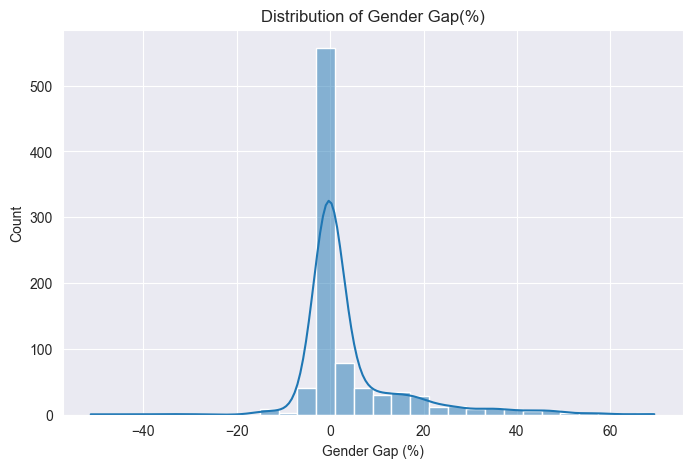

Mean:  4.1368271134389305
Median:  0.0
Skewness:  1.9971939338195046


In [88]:
# Basic Distribution of the Gap
plt.figure(figsize = (8, 5))
sns.histplot(df5["gender_gap_pct"], kde = True, bins = 30)
plt.title("Distribution of Gender Gap(%)")
plt.xlabel("Gender Gap (%)")
plt.show()

print("Mean: ", df5["gender_gap_pct"].mean())
print("Median: ", df5["gender_gap_pct"].median())
print("Skewness: ", df5["gender_gap_pct"].skew())

### The gender gap distribution is positively skewed, indicating that while most countries have narrowed literacy disparities between males and females, a small group of countries still experience significant inequality.

In [89]:
# Testing for Normality
stat, p_value = shapiro(df5['gender_gap_pct'])
print("Shapiro-Wilk Test Statistic: ", stat)
print("p_value: ", p_value)

if p_value > 0.05:
    print("Gender Gap distribution is approximately normal.")
else:
    print("Gender Gap distribution is NOT normal.")

Shapiro-Wilk Test Statistic:  0.6753834337980555
p_value:  3.198561478383307e-38
Gender Gap distribution is NOT normal.


In [90]:
# Since distribution is non-normal we move to non-paramteric tests
# Drop NaNs
gap = df5['gender_gap_pct'].dropna()

# Wilcoxon test against 0
stat, p_value = wilcoxon(gap - 0)
print("Wilcoxon test statistic:", stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Median gender gap is statistically significantly different from 0.")
else:
    print("Median gender gap is not significantly different from 0.")

Wilcoxon test statistic: 86121.0
p-value: 2.0328510135862424e-12
Median gender gap is statistically significantly different from 0.


### Parity not Acheived

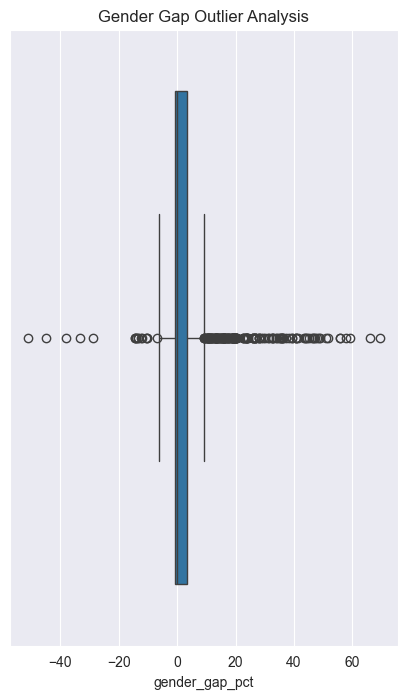

In [91]:
## Boxplot for Outliers
plt.figure(figsize = (5, 8))
sns.boxplot(x = df5["gender_gap_pct"])
plt.title("Gender Gap Outlier Analysis")
plt.show()

### Although the majority of countries are close to gender parity, extreme outliers highlight regions where female literacy continues to lag significantly. This shows uneven progress.

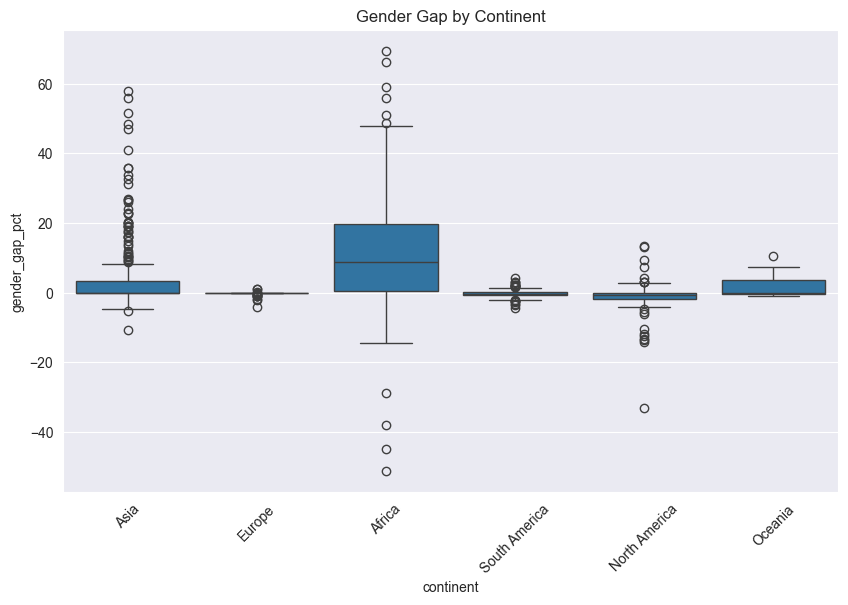

In [92]:
# Continental Comparison
plt.figure(figsize = (10, 6))
sns.boxplot(x = "continent", y = "gender_gap_pct", data = df5)
plt.xticks(rotation = 45)
plt.title("Gender Gap by Continent")
plt.show()

### Gender literacy disparities show strong regional clustering, suggesting that cultural, socio-economic, and policy frameworks play a significant role in education equity.

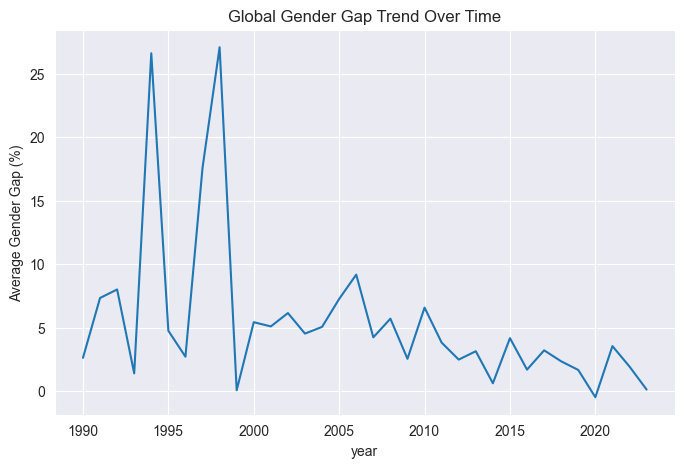

In [93]:
# Trend of Gender Gap Reduction
global_gap = df5.groupby("year")["gender_gap_pct"].mean()

plt.figure(figsize = (8, 5))
global_gap.plot()
plt.title("Global Gender Gap Trend Over Time")
plt.ylabel("Average Gender Gap (%)")
plt.show()

### The global gender literacy gap has steadily declined over time, reflecting progress in female educational access and policy reforms.

## Sudden Growth Spikes

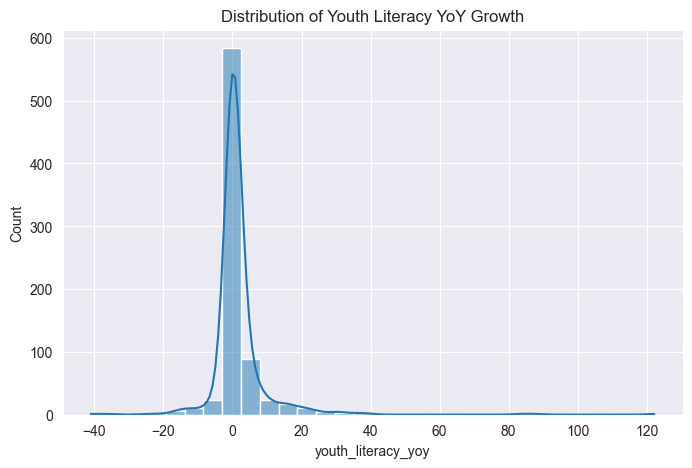

Mean:  1.8102652585902248
Skewness:  6.091658054198999


In [94]:
# Distribution of YoY Growth
plt.figure(figsize = (8, 5))
sns.histplot(df5["youth_literacy_yoy"].dropna(), kde = True, bins = 30)
plt.title("Distribution of Youth Literacy YoY Growth")
plt.show()

print("Mean: ", df5["youth_literacy_yoy"].mean())
print("Skewness: ", df5["youth_literacy_yoy"].skew())

### Most countries experience gradual literacy improvements, but a small group shows sharp year-over-year increases, likely driven by structural reforms or improved reporting systems.

In [95]:
# Identify Extreme Spikes
spikes = df5[df5["youth_literacy_yoy"] > 8]
spikes[["country", "year", "youth_literacy_yoy"]].sort_values(by = "youth_literacy_yoy", ascending = False)

,country,year,youth_literacy_yoy
29,Bangladesh,2000,122.222222
554,Niger,2005,87.500000
556,Niger,2012,83.299389
543,Nepal,2001,39.603960
111,Burundi,2000,37.383178
...,...,...,...
409,Kuwait,2005,8.695652
706,Sierra Leone,2013,8.672033
692,Senegal,2017,8.281308
261,Egypt,2022,8.142045


### While global literacy growth is generally incremental, several countries exhibit sharp year-over-year increases exceeding 8%, suggesting either rapid policy-driven reform or statistical adjustments in reporting.

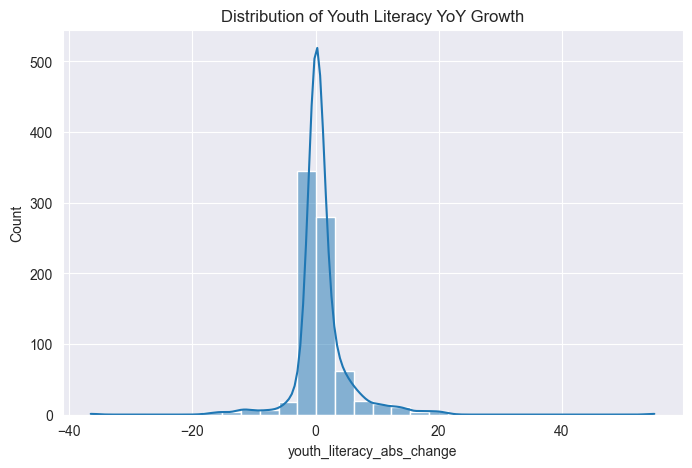

1     -11.468926
14    -13.415053
30    -36.500000
33     -6.921241
55     -6.442570
112   -15.081633
119    -8.712418
124    -8.839080
129   -10.216867
135   -12.425076
137   -24.744858
183   -11.912263
186   -15.796748
190   -20.426201
260    -5.162194
300    -6.405990
302    -5.225434
367    -6.185000
427    -5.607143
429    -5.044984
433   -17.032967
480   -12.431538
527    -6.088710
555   -41.080000
669    -9.660256
684    -7.636364
688   -14.285714
693    -5.779279
767   -16.455696
793   -14.773006
836    -7.780000
891   -12.720348
Name: youth_literacy_yoy, dtype: float64

In [96]:
# Absolute Change Distribution
plt.figure(figsize = (8, 5))
sns.histplot(df5["youth_literacy_abs_change"].dropna(), kde = True, bins = 30)
plt.title("Distribution of Youth Literacy YoY Growth")
plt.show()

declines = df5[df5["youth_literacy_yoy"] < -5]
declines["youth_literacy_yoy"]

### These negative spikes may reflect conflict, economic crises, or educational system collapse.

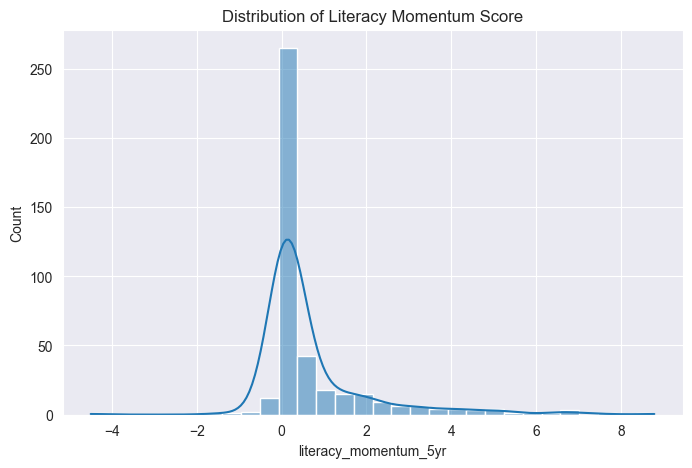

Mean:  0.6883178341346152
Skewness:  2.5901824275720284


In [97]:
# 5-Year Momentum
plt.figure(figsize = (8, 5))
sns.histplot(df5["literacy_momentum_5yr"].dropna(), kde = True, bins = 30)
plt.title("Distribution of Literacy Momentum Score")
plt.show()

print("Mean: ", df5["literacy_momentum_5yr"].mean())
print("Skewness: ", df5["literacy_momentum_5yr"].skew())

### While year-over-year literacy growth is highly volatile and dominated by extreme spikes, the 5-year momentum distribution is significantly more stable. This suggests that long-term educational progress is gradual and systemic rather than sudden.

In [98]:
momentum = df5['literacy_momentum_5yr'].dropna()
stat, p_value = wilcoxon(momentum - 0)
print("Wilcoxon test statistic:", stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Median 5-Year Momentum is significantly different from 0.")
else:
    print("Median 5-Year Momentum is not significantly different from 0.")

Wilcoxon test statistic: 4049.5
p-value: 1.8266519763134023e-51
Median 5-Year Momentum is significantly different from 0.


### Across countries, the typical (median) 5-year change in literacy is non-zero. Most countries are experiencing actual improvements in literacy, not just random fluctuations. The momentum is structurally positive, showing global literacy is generally increasing over 5-year periods.

### The relationship between log GDP per capita and adult literacy rate is strongly positive and approximately linear at lower and middle income levels. However, a clear ceiling effect emerges among high-income countries, where literacy rates plateau near universal levels. Additionally, substantial variation among low-income nations suggests that governance and policy efficiency significantly influence literacy outcomes beyond economic capacity alone.


### The literacy index exhibits a strong positive association with log GDP per capita, displaying a clear three-phase development pattern: high variability at low income levels, rapid gains during middle-income transitions, and saturation at high income levels. Compared to raw literacy rates, the composite literacy index demonstrates a more structured and stable economic relationship.

### Youth literacy demonstrates a strong positive association with GDP per capita and exhibits faster convergence toward universal levels compared to adult literacy. This suggests that economic development translates more immediately into improved educational access for younger populations, while adult literacy reflects historical educational conditions.